In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.neighbors import NearestNeighbors
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
class CDSMOTE:
    def __init__(self, k_clusters=3, k_neighbors=5, random_state=42, verbose=True):
        self.k_clusters = k_clusters
        self.k_neighbors = k_neighbors
        self.random_state = random_state
        self.verbose = verbose

    def fit_resample(self, df, label_col="label_3"):
        id_cols = ["user_id", "course_id"]
        feature_cols = [c for c in df.columns if c not in id_cols + [label_col]]

        # ===== 0. CHUẨN HÓA =====
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df[feature_cols].values)
        y = df[label_col].astype(str).values

        classes, counts = np.unique(y, return_counts=True)
        majority_class = classes[np.argmax(counts)]

        if self.verbose:
            print("\nBắt đầu xử lý dữ liệu")
            print(f"Lớp đa số: {majority_class} ({counts.max()} mẫu)")

        # ===== 1. PHÂN CỤM =====
        cluster_labels = np.empty(len(y), dtype=object)
        
        for cls in classes:
            idx = np.where(y == cls)[0]
            n_samples = len(idx)

            if n_samples < self.k_clusters:
                k = 1
            else:
                k = self.k_clusters
            
            if self.verbose:
                print(f"Lớp {cls} được chia thành {k} cụm")

            kmeans = KMeans(
                n_clusters=k,
                init="random",   
                n_init=10,
                random_state=self.random_state
            )
            labels = kmeans.fit_predict(X_scaled[idx])
            unique, counts = np.unique(labels, return_counts=True)

            if self.verbose:
                for u, c in zip(unique, counts):
                    print(f"    Cụm {u}: {c} mẫu")
            for i, lab in enumerate(labels):
                cluster_labels[idx[i]] = f"{cls}_c{lab}"

        unique_clusters, cluster_counts = np.unique(cluster_labels, return_counts=True)

        cluster_data = {uc: X_scaled[cluster_labels == uc] for uc in unique_clusters}
        cluster_sizes = dict(zip(unique_clusters, cluster_counts))

        if self.verbose:
            print("\nDanh sách cụm:")
            for uc in unique_clusters:
                print(f"  - {uc}: {cluster_sizes[uc]} mẫu")

        # ===== 2. RESAMPLING =====
        new_samples_list = []

        # TÍNH TOÁN MỤC TIÊU TỔNG THỂ (Dựa trên lớp đa số)
        max_count = df[label_col].value_counts().max()

        for cls in classes:
            if cls == majority_class:
                continue

            if self.verbose:
                print(f"\nĐang xử lý lớp {cls}")

            min_clusters = [uc for uc in unique_clusters if uc.startswith(f"{cls}_")]
            maj_clusters = [uc for uc in unique_clusters if uc.startswith(f"{majority_class}_")]
            
            n_clusters_min = len(min_clusters)
            if n_clusters_min == 0: continue
            
            # Chia đều chỉ tiêu để tổng lớp đạt đúng bằng lớp đa số
            target_size_per_cluster = max_count // n_clusters_min 
            # ------------------------------------------------------

            for min_c in min_clusters:
                X_min = cluster_data[min_c]
                n_min = len(X_min)
                
                if n_min < 2:
                    if self.verbose: print(f"  - Bỏ qua {min_c}: quá ít mẫu")
                    continue

                # ===== TÌM CỤM ĐA SỐ GẦN NHẤT =====
                min_center = np.mean(X_min, axis=0).reshape(1, -1)
                maj_centers = np.array([np.mean(cluster_data[mc], axis=0) for mc in maj_clusters])

                distances = pairwise_distances(min_center, maj_centers)
                closest_idx = np.argmin(distances)
                matched_maj_cluster = maj_clusters[closest_idx]

                # --- [ĐOẠN SỬA 2]: BUNG HẾT CÔNG SUẤT ---
                X_maj = cluster_data[matched_maj_cluster] 
                n_maj = len(X_maj)

                target_size = target_size_per_cluster
                # ----------------------------------------

                if self.verbose:
                    print(f"\n  - Cụm thiểu số: {min_c} ({n_min} mẫu)")
                    print(f"    Ghép với cụm đa số: {matched_maj_cluster} ({n_maj} mẫu)")
                    print(f"    Target size: {target_size}")

                if target_size <= n_min:
                    continue

                # ===== TẠO DATASET CON VÀ SMOTE =====
                X_sub = np.vstack([X_min, X_maj])
                y_sub = np.array([0] * n_min + [1] * n_maj)

                k_eff = max(1, min(self.k_neighbors, n_min - 1))

                smoter = SMOTE(
                    sampling_strategy={0: target_size}, # Nhãn 0 là lớp thiểu số
                    k_neighbors=k_eff,
                    random_state=self.random_state
                )
                
                try:
                    X_res, y_res = smoter.fit_resample(X_sub, y_sub)
                    if len(X_res) == len(X_sub):
                        if self.verbose:
                            print("    SMOTE không sinh thêm mẫu")
                        continue

                    n_generated = target_size - n_min
                    X_syn_scaled = X_res[len(X_sub): len(X_sub) + n_generated]

                    if len(X_syn_scaled) == 0:
                        continue

                    X_syn_original = scaler.inverse_transform(X_syn_scaled)

                    df_syn = pd.DataFrame(X_syn_original, columns=feature_cols)
                    df_syn[label_col] = cls

                    # ===== GÁN ID =====
                    for col in id_cols:
                        if col in df.columns:
                            original_ids = df[df[label_col].astype(str) == cls][col].values
                            
                            if len(original_ids) == 0:
                                if self.verbose:
                                    print(f"    Bỏ qua gán ID cho {col}: không có dữ liệu")
                                continue
                    
                            df_syn[col] = np.random.choice(original_ids, size=len(df_syn))

                    new_samples_list.append(df_syn)

                    if self.verbose:
                        print(f"    Đã sinh thêm {len(df_syn)} mẫu")

                except Exception as e:
                    if self.verbose:
                        print(f"    Lỗi khi sinh mẫu: {e}")
                    continue

        # ===== 3. GHÉP DỮ LIỆU =====
        if new_samples_list:
            df_final = pd.concat([df] + new_samples_list, axis=0, ignore_index=True)
        
            df_final[LABEL_COL] = df_final[LABEL_COL].astype(int)
        
            if self.verbose:
                print("\nHoàn tất tăng cường dữ liệu")
                print(f"Tổng số mẫu sau cùng: {len(df_final)}")
        
            return df_final.sample(frac=1, random_state=self.random_state).reset_index(drop=True)
        
        if self.verbose:
            print("\nKhông có mẫu nào được sinh thêm")
        
        return df.copy()

# Median imputation CDSMOTE

In [3]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Median/Median/train_median.csv"
LABEL_COL = "label_3"

df_median = pd.read_csv(INPUT_FILE)
print(f"Đã đọc file: {df_median.shape}")
df_median

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176,2020,2,6,170,2,2.0,6,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1,140538,475,114,2020,10,30,76,2,0.0,58,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
2,125447,750,170,2020,2,12,69,2,0.0,56,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
3,24957,17,151,2020,2,16,138,2,2.0,7,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
4,977326,468,173,2020,10,30,140,2,2.0,2,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91,2019,12,31,52,2,0.0,49,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859615,106770,862,121,2020,9,1,31,2,0.0,60,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859616,258729,833,93,2020,4,13,91,2,2.0,2,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0
1859617,969906,616,121,2020,9,1,37,2,1.0,3,...,8.0,33.0,1.0,0.615991,31.0,0.0,0.0,0.818182,0.0,0.0


In [4]:
# Chạy cdsmote
print(f"Phân bố label trước CDSMOTE:")
print(df_median[LABEL_COL].value_counts().sort_index())

cdsmote = CDSMOTE(verbose=True)
df_balanced = cdsmote.fit_resample(df_median, label_col="label_3")

print(f"\nPhân bố label sau CDSMOTE:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước CDSMOTE:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

Bắt đầu xử lý dữ liệu
Lớp đa số: 2 (1852997 mẫu)
Lớp 0 được chia thành 3 cụm
    Cụm 0: 259 mẫu
    Cụm 1: 1186 mẫu
    Cụm 2: 338 mẫu
Lớp 1 được chia thành 3 cụm
    Cụm 0: 546 mẫu
    Cụm 1: 3905 mẫu
    Cụm 2: 388 mẫu
Lớp 2 được chia thành 3 cụm
    Cụm 0: 77394 mẫu
    Cụm 1: 1772816 mẫu
    Cụm 2: 2787 mẫu

Danh sách cụm:
  - 0_c0: 259 mẫu
  - 0_c1: 1186 mẫu
  - 0_c2: 338 mẫu
  - 1_c0: 546 mẫu
  - 1_c1: 3905 mẫu
  - 1_c2: 388 mẫu
  - 2_c0: 77394 mẫu
  - 2_c1: 1772816 mẫu
  - 2_c2: 2787 mẫu

Đang xử lý lớp 0

  - Cụm thiểu số: 0_c0 (259 mẫu)
    Ghép với cụm đa số: 2_c2 (2787 mẫu)
    Target size: 617665
    Đã sinh thêm 617406 mẫu

  - Cụm thiểu số: 0_c1 (1186 mẫu)
    Ghép với cụm đa số: 2_c1 (1772816 mẫu)
    Target size: 617665
    Đã sinh thêm 616479 mẫu

  - Cụm thiểu số: 0_c2 (338 mẫu)
    Ghép với cụm đa số: 2_c0 (77394 mẫu)
    Target size: 617665
    Đã sinh thêm 617327 

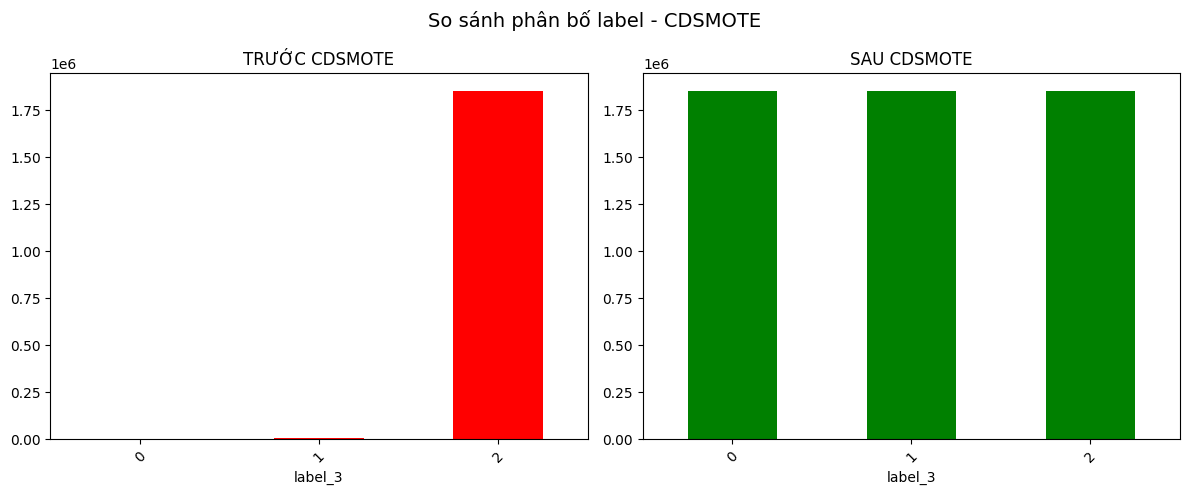

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_median[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC CDSMOTE", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU CDSMOTE", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - CDSMOTE", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
df_balanced.to_parquet("train_median_cdsmote.parquet", index=False)

# Mean imputation CDSMOTE

In [7]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Mean/Mean/train_mean.csv"
LABEL_COL = "label_3"

df_mean = pd.read_csv(INPUT_FILE)
print(f"Đã đọc file: {df_mean.shape}")
df_mean

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176,2020,2,6,170,2,2.0,6,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1,140538,475,114,2020,10,30,76,2,0.0,58,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
2,125447,750,170,2020,2,12,69,2,0.0,56,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
3,24957,17,151,2020,2,16,138,2,2.0,7,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
4,977326,468,173,2020,10,30,140,2,2.0,2,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91,2019,12,31,52,2,0.0,49,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859615,106770,862,121,2020,9,1,31,2,0.0,60,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859616,258729,833,93,2020,4,13,91,2,2.0,2,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781
1859617,969906,616,121,2020,9,1,37,2,1.0,3,...,37.895714,151.214508,1.305472,0.633849,29.86416,0.009356,0.241014,0.685691,0.073295,0.28781


In [8]:
# Chạy cdsmote
print(f"Phân bố label trước CDSMOTE:")
print(df_mean[LABEL_COL].value_counts().sort_index())

cdsmote = CDSMOTE(verbose=True)
df_balanced = cdsmote.fit_resample(df_mean, label_col="label_3")

print(f"\nPhân bố label sau CDSMOTE:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước CDSMOTE:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

Bắt đầu xử lý dữ liệu
Lớp đa số: 2 (1852997 mẫu)
Lớp 0 được chia thành 3 cụm
    Cụm 0: 351 mẫu
    Cụm 1: 1200 mẫu
    Cụm 2: 232 mẫu
Lớp 1 được chia thành 3 cụm
    Cụm 0: 932 mẫu
    Cụm 1: 345 mẫu
    Cụm 2: 3562 mẫu
Lớp 2 được chia thành 3 cụm
    Cụm 0: 1136959 mẫu
    Cụm 1: 713108 mẫu
    Cụm 2: 2930 mẫu

Danh sách cụm:
  - 0_c0: 351 mẫu
  - 0_c1: 1200 mẫu
  - 0_c2: 232 mẫu
  - 1_c0: 932 mẫu
  - 1_c1: 345 mẫu
  - 1_c2: 3562 mẫu
  - 2_c0: 1136959 mẫu
  - 2_c1: 713108 mẫu
  - 2_c2: 2930 mẫu

Đang xử lý lớp 0

  - Cụm thiểu số: 0_c0 (351 mẫu)
    Ghép với cụm đa số: 2_c0 (1136959 mẫu)
    Target size: 617665
    Đã sinh thêm 617314 mẫu

  - Cụm thiểu số: 0_c1 (1200 mẫu)
    Ghép với cụm đa số: 2_c1 (713108 mẫu)
    Target size: 617665
    Đã sinh thêm 616465 mẫu

  - Cụm thiểu số: 0_c2 (232 mẫu)
    Ghép với cụm đa số: 2_c0 (1136959 mẫu)
    Target size: 617665
    Đã sinh thêm 6

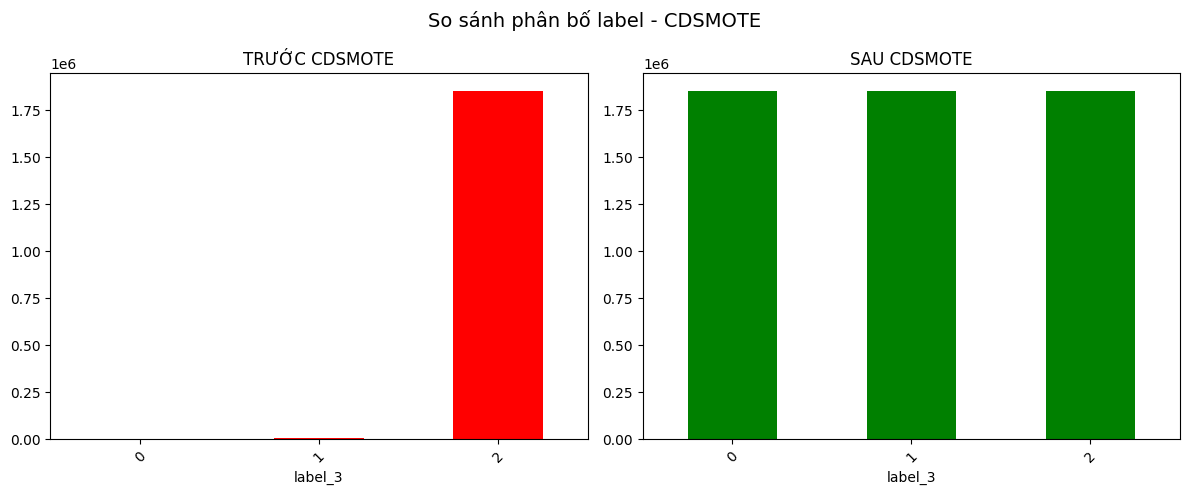

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_mean[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC CDSMOTE", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU CDSMOTE", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - CDSMOTE", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
df_balanced.to_parquet("train_mean_cdsmote.parquet", index=False)

# Extra_trees imputation CDSMOTE

In [11]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Extra_trees/Extra_trees/train_extra.csv"
LABEL_COL = "label_3"

df_Extra_trees = pd.read_csv(INPUT_FILE)
print(f"Đã đọc file: {df_Extra_trees.shape}")
df_Extra_trees

Đã đọc file: (1859619, 182)


,user_id,course_id,course_duration,start_year,start_month,start_day,enrollment_to_end,label_3,gender,num_course_order,...,cmt_p4_max_comment_length_phase4,cmt_p4_text_diversity_phase4,cmt_p4_comment_days_active_phase4,cmt_p4_entropy_time_mean_phase4,cmt_p4_most_common_time_bin_phase4,cmt_p4_time_entropy_var_phase4,cmt_p4_positive_ratio_phase4,cmt_p4_neutral_ratio_phase4,cmt_p4_negative_ratio_phase4,cmt_p4_sentiment_entropy_phase4
0,418060,542,176.0,2020.0,2.0,6.0,170.0,2,2.0,6.0,...,31.651376,94.035489,1.404973,0.658513,30.639715,0.000108,0.067268,0.919406,0.145252,0.273137
1,140538,475,114.0,2020.0,10.0,30.0,76.0,2,0.0,58.0,...,31.651376,94.035489,1.404973,0.658513,30.639715,0.000108,0.067268,0.919406,0.253264,0.273137
2,125447,750,170.0,2020.0,2.0,12.0,69.0,2,0.0,56.0,...,31.651376,94.035489,1.404973,0.658513,30.639715,0.000108,0.067268,0.919406,0.145252,0.273137
3,24957,17,151.0,2020.0,2.0,16.0,138.0,2,2.0,7.0,...,31.651376,94.035489,1.404973,0.658513,30.639715,0.000108,0.067268,0.919406,0.253264,0.273137
4,977326,468,173.0,2020.0,10.0,30.0,140.0,2,2.0,2.0,...,31.651376,94.035489,1.404973,0.658513,30.639715,0.000108,0.067268,0.919406,0.145252,0.273137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859614,160452,856,91.0,2019.0,12.0,31.0,52.0,2,0.0,49.0,...,33.878750,94.035489,1.404973,0.658513,30.639715,0.000108,0.067268,0.919406,0.145252,0.273137
1859615,106770,862,121.0,2020.0,9.0,1.0,31.0,2,0.0,60.0,...,31.651376,94.035489,1.404973,0.658513,30.639715,0.000108,0.067268,0.919406,0.145252,0.273137
1859616,258729,833,93.0,2020.0,4.0,13.0,91.0,2,2.0,2.0,...,31.651376,94.035489,1.404973,0.658513,30.639715,0.000108,0.067268,0.919406,0.145252,0.273137
1859617,969906,616,121.0,2020.0,9.0,1.0,37.0,2,1.0,3.0,...,31.651376,94.035489,1.404973,0.658513,30.639715,0.000108,0.067268,0.919406,0.145252,0.273137


In [12]:
# Chạy cdsmote
print(f"Phân bố label trước CDSMOTE:")
print(df_Extra_trees[LABEL_COL].value_counts().sort_index())

cdsmote = CDSMOTE(verbose=True)
df_balanced = cdsmote.fit_resample(df_Extra_trees, label_col="label_3")

print(f"\nPhân bố label sau CDSMOTE:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

Phân bố label trước CDSMOTE:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64

Bắt đầu xử lý dữ liệu
Lớp đa số: 2 (1852997 mẫu)
Lớp 0 được chia thành 3 cụm
    Cụm 0: 198 mẫu
    Cụm 1: 1338 mẫu
    Cụm 2: 247 mẫu
Lớp 1 được chia thành 3 cụm
    Cụm 0: 360 mẫu
    Cụm 1: 337 mẫu
    Cụm 2: 4142 mẫu
Lớp 2 được chia thành 3 cụm
    Cụm 0: 1220478 mẫu
    Cụm 1: 459531 mẫu
    Cụm 2: 172988 mẫu

Danh sách cụm:
  - 0_c0: 198 mẫu
  - 0_c1: 1338 mẫu
  - 0_c2: 247 mẫu
  - 1_c0: 360 mẫu
  - 1_c1: 337 mẫu
  - 1_c2: 4142 mẫu
  - 2_c0: 1220478 mẫu
  - 2_c1: 459531 mẫu
  - 2_c2: 172988 mẫu

Đang xử lý lớp 0

  - Cụm thiểu số: 0_c0 (198 mẫu)
    Ghép với cụm đa số: 2_c0 (1220478 mẫu)
    Target size: 617665
    Đã sinh thêm 617467 mẫu

  - Cụm thiểu số: 0_c1 (1338 mẫu)
    Ghép với cụm đa số: 2_c0 (1220478 mẫu)
    Target size: 617665
    Đã sinh thêm 616327 mẫu

  - Cụm thiểu số: 0_c2 (247 mẫu)
    Ghép với cụm đa số: 2_c2 (172988 mẫu)
    Target size: 617665
    Đã sinh th

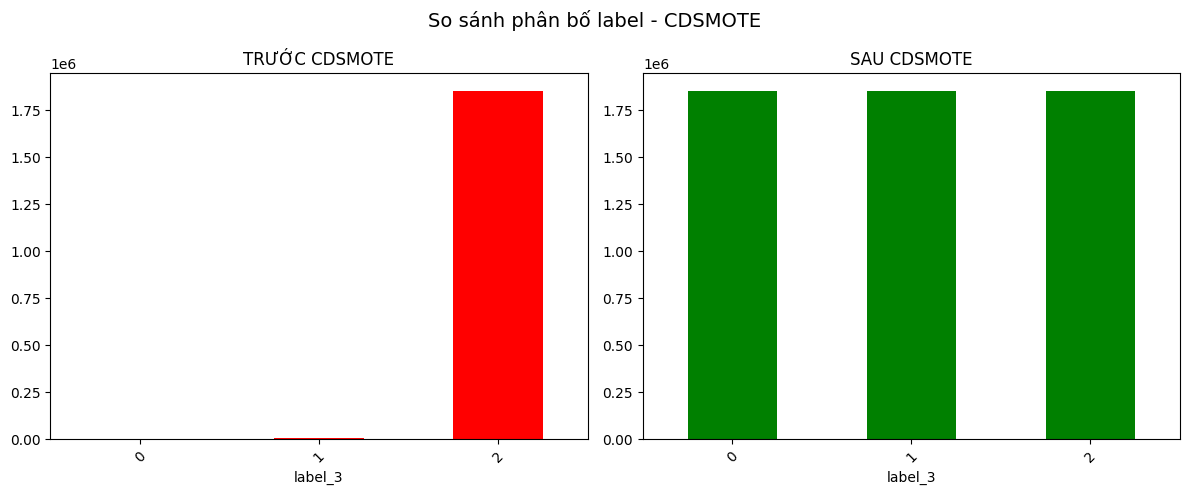

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_Extra_trees[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC CDSMOTE", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU CDSMOTE", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - CDSMOTE", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
df_balanced.to_parquet("train_Extra_trees_cdsmote.parquet", index=False)